# Categorical Feature Exploration

**Datasets:** `freMTPL2freq` and `bemtpl` from CASdatasets (R package)  
**Purpose:** Inspect the distribution and mean claim rate for every categorical and ordinal
feature to inform encoding decisions. No preprocessing is applied — data is loaded raw from R.

**How to use:**
1. Run all cells top to bottom.
2. For each feature: check the value counts table and the bar chart.
3. Record your encoding decisions in the **Encoding decisions** cell at the bottom.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

In [ ]:
def load_casdataset(name: str) -> pd.DataFrame:
    """Load a named dataset from the CASdatasets R package via rpy2."""
    try:
        importr("CASdatasets")
    except Exception as e:
        raise ImportError(
            "CASdatasets R package not found. "
            "See environment.txt Step 4 for installation instructions."
        ) from e
    ro.r(f"data({name})")
    with localconverter(ro.default_converter + pandas2ri.converter):
        df = ro.conversion.rpy2py(ro.r[name])
    # R factors arrive as pandas Categorical -- convert to plain strings
    for col in df.select_dtypes("category").columns:
        df[col] = df[col].astype(str)
    return df


print("Loading freMTPL2freq ...")
df_freq = load_casdataset("freMTPL2freq")
print(f"  {df_freq.shape[0]:,} rows x {df_freq.shape[1]} columns")

print("Loading freMTPL2sev ...")
df_sev = load_casdataset("freMTPL2sev")
print(f"  {df_sev.shape[0]:,} rows x {df_sev.shape[1]} columns")

print("Loading beMTPL97 ...")
df_bemtpl = load_casdataset("beMTPL97")
print(f"  {df_bemtpl.shape[0]:,} rows x {df_bemtpl.shape[1]} columns")

Loading freMTPL2freq ...
  677,991 rows x 12 columns
Loading freMTPL2sev ...
  26,444 rows x 2 columns
Loading beMTPL97 ...
  163,212 rows x 18 columns


In [3]:
def explore_feature(
    df: pd.DataFrame,
    col: str,
    response_col: str,
    exposure_col: str,
    order,
    figsize_base: tuple = (10, 4),
) -> None:
    """
    Display value counts, mean claim-rate table, and bar chart for one feature.

    Parameters
    ----------
    order : 'rate' | 'natural' | list
        'rate'    - sort levels by mean claim rate, descending.
        'natural' - sort levels by their own value, ascending (numeric ordinals).
        list      - explicit ordering, e.g. ['TPL', 'TPL+', 'TPL++'].
    """
    n_levels = df[col].nunique()

    # -- Value counts --------------------------------------------------------
    counts = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    counts["pct"] = (counts["count"] / len(df) * 100).round(2)

    # -- Aggregate claims and exposure per level ------------------------------
    agg = (
        df.groupby(col, observed=True)
        .agg(
            n_policies=(response_col, "count"),
            sum_claims=(response_col, "sum"),
            sum_exposure=(exposure_col, "sum"),
        )
        .reset_index()
    )
    agg["mean_rate"] = agg["sum_claims"] / agg["sum_exposure"]

    summary = agg.merge(counts[[col, "count", "pct"]], on=col)

    # -- Apply ordering ------------------------------------------------------
    if order == "rate":
        summary = summary.sort_values("mean_rate", ascending=False)
    elif order == "natural":
        try:
            summary[col] = pd.to_numeric(summary[col])
        except (ValueError, TypeError):
            pass
        summary = summary.sort_values(col)
    else:  # explicit list
        summary[col] = pd.Categorical(summary[col], categories=order, ordered=True)
        summary = summary.sort_values(col)

    x_labels = summary[col].astype(str).tolist()

    # -- Header and summary table --------------------------------------------
    display(Markdown("---"))
    display(Markdown(f"### `{col}` &nbsp; ({n_levels} levels)"))
    display(
        summary[
            [col, "count", "pct", "n_policies", "sum_claims", "sum_exposure", "mean_rate"]
        ]
        .reset_index(drop=True)
        .style.format(
            {
                "count": "{:,.0f}",
                "pct": "{:.2f}%",
                "n_policies": "{:,.0f}",
                "sum_claims": "{:,.1f}",
                "sum_exposure": "{:,.1f}",
                "mean_rate": "{:.6f}",
            }
        )
    )

    # -- Bar chart -----------------------------------------------------------
    # Cap width at 28 inches; wide charts can be scrolled horizontally in JupyterLab.
    fig_w = min(max(figsize_base[0], n_levels * 0.40), 28)
    fig, ax = plt.subplots(figsize=(fig_w, figsize_base[1]))
    ax.bar(
        range(n_levels),
        summary["mean_rate"].tolist(),
        color="steelblue",
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xticks(range(n_levels))
    rotation = 90 if n_levels > 15 else (45 if n_levels > 6 else 0)
    ha = "right" if 0 < rotation < 90 else "center"
    ax.set_xticklabels(x_labels, rotation=rotation, ha=ha, fontsize=9)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Mean claim rate", fontsize=10)
    ax.set_title(f"Mean claim rate by {col}", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.5f"))
    plt.tight_layout()
    plt.show()

---
## 1. French MTPL &mdash; `freMTPL2freq`

**Response:** `ClaimNb` (number of claims per policy)  
**Exposure:** `Exposure` (policy-years)  
**Claim rate:** `sum(ClaimNb) / sum(Exposure)` claims per exposure-year

In [4]:
print(f"Shape: {df_freq.shape[0]:,} rows x {df_freq.shape[1]} columns")
print()
print("Column dtypes:")
print(df_freq.dtypes.to_string())
print()
overall_rate = df_freq["ClaimNb"].sum() / df_freq["Exposure"].sum()
pct_with_claim = (df_freq["ClaimNb"] > 0).mean()
print(f"Overall claim rate : {overall_rate:.6f} claims / exposure-year")
print(f"Policies with claim: {pct_with_claim:.4%}")
print()
display(df_freq.head())

Shape: 677,991 rows x 12 columns

Column dtypes:
IDpol             str
ClaimNb       float64
Exposure      float64
VehPower        int32
VehAge          int32
DrivAge         int32
BonusMalus      int32
VehBrand          str
VehGas            str
Area              str
Density         int32
Region            str

Overall claim rate : 0.073766 claims / exposure-year
Policies with claim: 3.6791%



,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
1,1,0.000000,0.100000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,3,0.000000,0.770000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
3,5,0.000000,0.750000,6,2,52,50,B12,Diesel,B,54,Picardie
4,10,0.000000,0.090000,7,0,46,50,B12,Diesel,B,76,Aquitaine
5,11,0.000000,0.840000,7,0,46,50,B12,Diesel,B,76,Aquitaine


---

### `Area` &nbsp; (6 levels)

,Area,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,A,"103,952",15.33%,"103,952","3,364.0","61,966.1",0.054288
1,B,"75,457",11.13%,"75,457","2,633.0","43,010.8",0.061217
2,C,"191,874",28.30%,"191,874","7,093.0","104,443.2",0.067913
3,D,"151,592",22.36%,"151,592","6,458.0","77,116.9",0.083743
4,E,"137,163",20.23%,"137,163","6,122.0","63,817.1",0.095930
5,F,"17,953",2.65%,"17,953",774.0,"8,128.8",0.095218


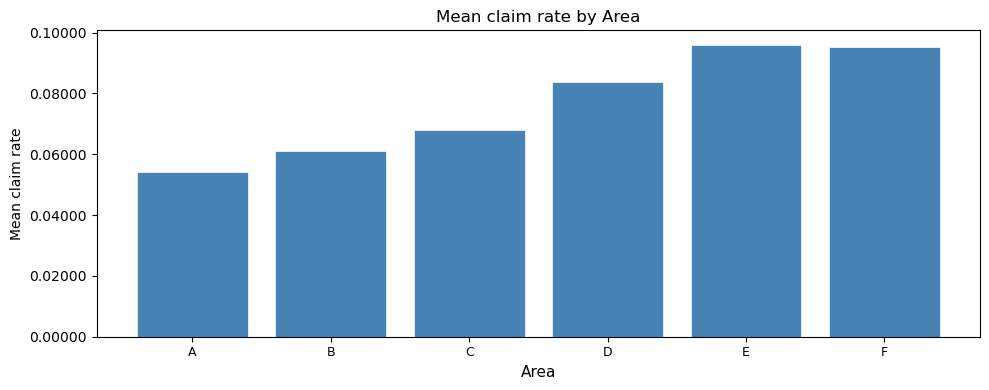

---

### `VehPower` &nbsp; (12 levels)

,VehPower,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,4,"115,344",17.01%,"115,344","4,003.0","60,069.7",0.066639
1,5,"124,815",18.41%,"124,815","5,115.0","68,168.8",0.075034
2,6,"148,972",21.97%,"148,972","6,305.0","82,520.4",0.076405
3,7,"145,398",21.45%,"145,398","5,593.0","77,948.4",0.071753
4,8,"46,954",6.93%,"46,954","1,645.0","22,682.9",0.072521
5,9,"30,084",4.44%,"30,084","1,220.0","15,348.1",0.079489
6,10,"31,353",4.62%,"31,353","1,217.0","15,374.4",0.079157
7,11,"18,352",2.71%,"18,352",714.0,"8,497.8",0.084022
8,12,"8,214",1.21%,"8,214",296.0,"3,792.0",0.078058
9,13,"3,229",0.48%,"3,229",139.0,"1,637.3",0.084898


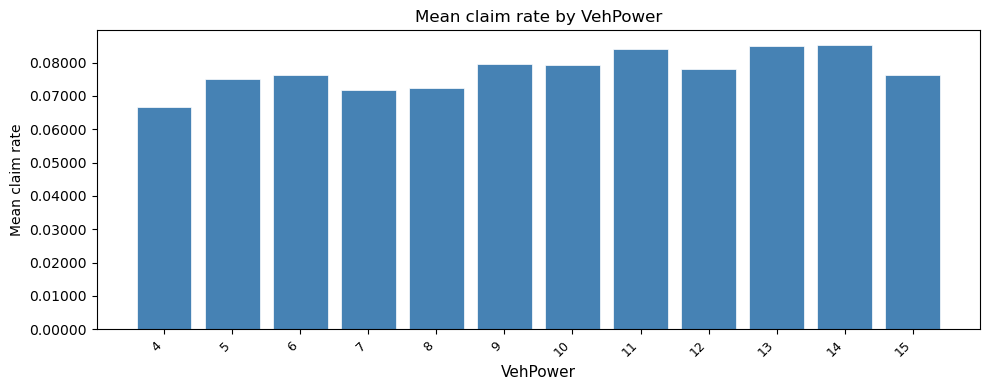

---

### `VehAge` &nbsp; (78 levels)

,VehAge,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,0,"57,739",8.52%,"57,739","1,181.0","16,719.0",0.070638
1,1,"71,279",10.51%,"71,279","2,328.0","32,746.2",0.071092
2,2,"59,122",8.72%,"59,122","2,238.0","29,705.9",0.075338
3,3,"50,261",7.41%,"50,261","1,873.0","26,081.4",0.071814
4,4,"43,491",6.41%,"43,491","1,793.0","23,759.0",0.075466
5,5,"38,736",5.71%,"38,736","1,678.0","22,197.8",0.075593
6,6,"35,715",5.27%,"35,715","1,671.0","20,786.9",0.080387
7,7,"32,880",4.85%,"32,880","1,657.0","19,254.2",0.086059
8,8,"32,679",4.82%,"32,679","1,489.0","19,231.4",0.077425
9,9,"31,921",4.71%,"31,921","1,549.0","18,781.0",0.082477


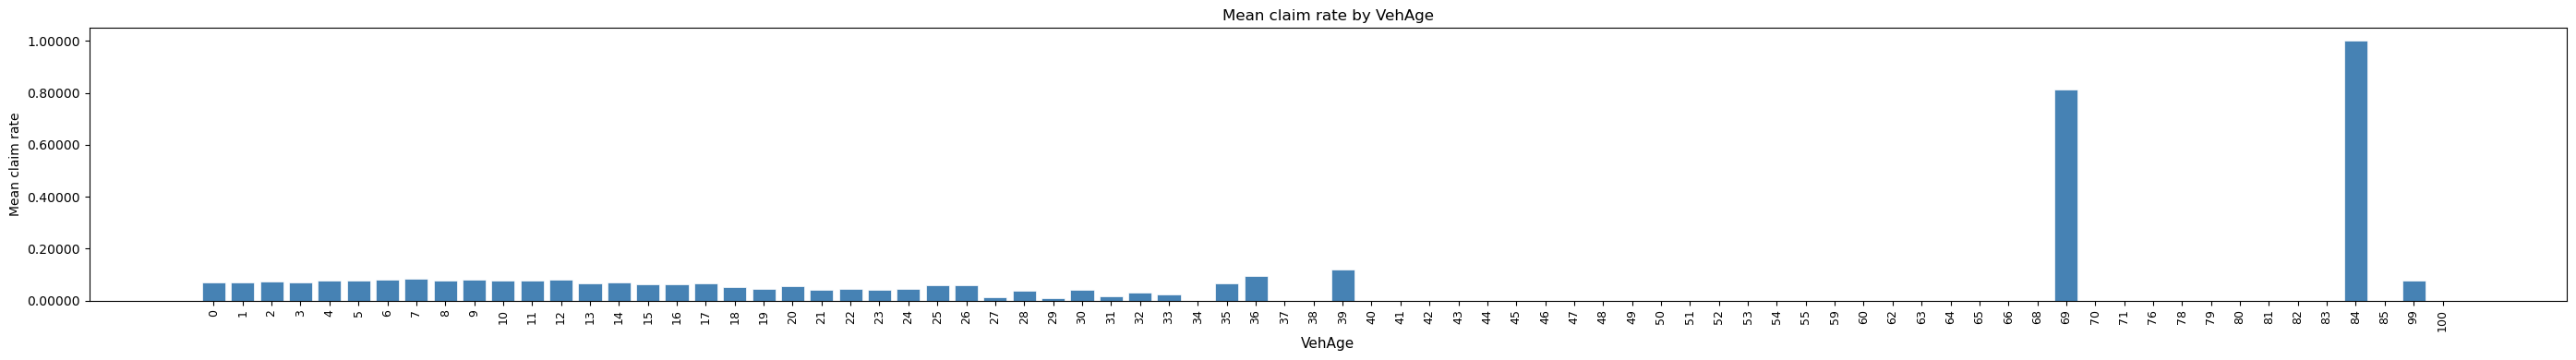

---

### `DrivAge` &nbsp; (83 levels)

,DrivAge,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,18,748,0.11%,748,64.0,210.7,0.303736
1,19,"2,392",0.35%,"2,392",240.0,912.9,0.262900
2,20,"3,676",0.54%,"3,676",313.0,"1,461.0",0.214240
3,21,"4,437",0.65%,"4,437",314.0,"1,820.1",0.172518
4,22,"5,290",0.78%,"5,290",340.0,"2,222.9",0.152956
5,23,"6,260",0.92%,"6,260",373.0,"2,671.7",0.139614
6,24,"7,393",1.09%,"7,393",367.0,"3,188.2",0.115113
7,25,"8,697",1.28%,"8,697",392.0,"3,738.7",0.104848
8,26,"10,301",1.52%,"10,301",455.0,"4,456.2",0.102104
9,27,"11,827",1.74%,"11,827",412.0,"5,199.7",0.079235


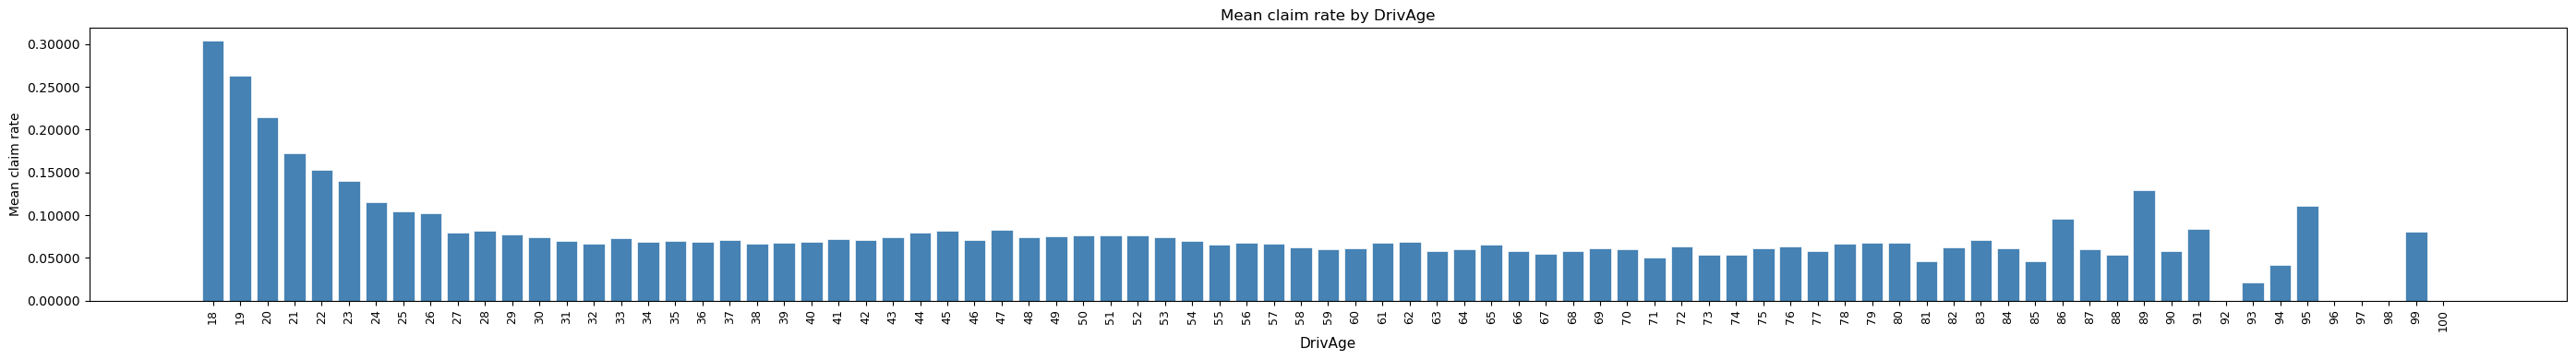

---

### `BonusMalus` &nbsp; (115 levels)

,BonusMalus,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,50,"384,142",56.66%,"384,142","11,592.0","225,222.5",0.051469
1,51,"15,869",2.34%,"15,869",420.0,"8,358.2",0.050250
2,52,"4,770",0.70%,"4,770",260.0,"2,726.0",0.095379
3,53,"3,351",0.49%,"3,351",160.0,"1,640.1",0.097554
4,54,"17,359",2.56%,"17,359",460.0,"8,700.6",0.052870
5,55,"5,593",0.82%,"5,593",340.0,"3,116.2",0.109107
6,56,"3,453",0.51%,"3,453",216.0,"1,783.4",0.121115
7,57,"17,937",2.65%,"17,937",487.0,"8,839.6",0.055093
8,58,"5,969",0.88%,"5,969",553.0,"3,217.4",0.171875
9,59,"2,779",0.41%,"2,779",138.0,"1,447.7",0.095326


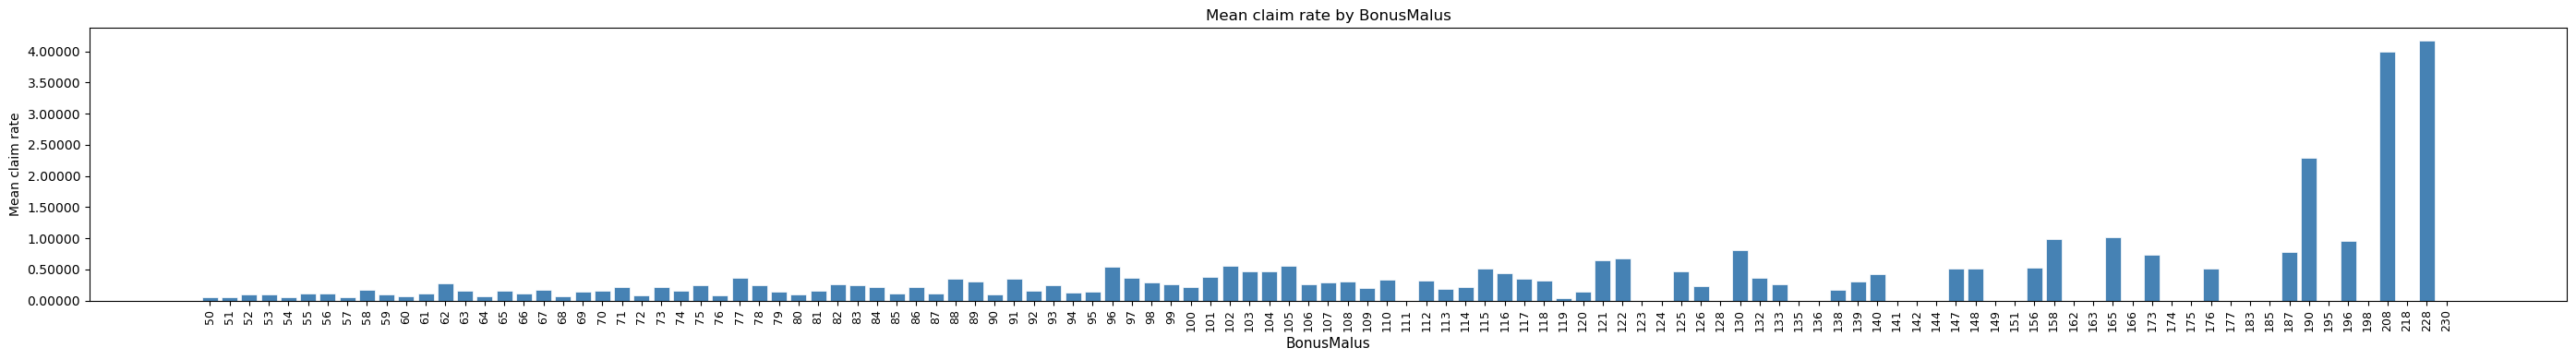

---

### `VehBrand` &nbsp; (11 levels)

,VehBrand,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,B11,"13,585",2.00%,"13,585",664.0,"6,887.8",0.096402
1,B3,"53,393",7.88%,"53,393","2,429.0","28,591.2",0.084956
2,B5,"34,752",5.13%,"34,752","1,662.0","19,991.1",0.083137
3,B10,"17,707",2.61%,"17,707",765.0,"9,496.0",0.080560
4,B6,"28,545",4.21%,"28,545","1,252.0","15,682.6",0.079834
5,B4,"25,179",3.71%,"25,179","1,099.0","13,775.5",0.079779
6,B13,"12,177",1.80%,"12,177",539.0,"6,771.4",0.079599
7,B1,"162,730",24.00%,"162,730","6,898.0","95,346.5",0.072347
8,B2,"159,854",23.58%,"159,854","6,805.0","94,858.8",0.071738
9,B12,"166,022",24.49%,"166,022","4,200.0","64,807.4",0.064807


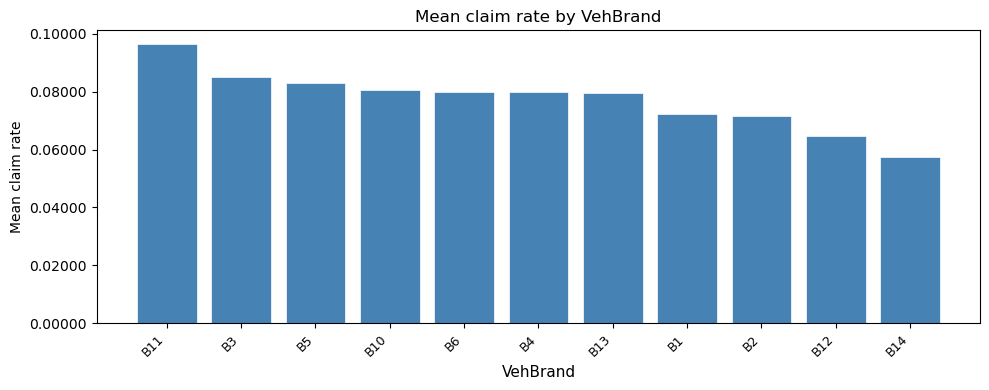

---

### `VehGas` &nbsp; (2 levels)

,VehGas,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,Diesel,"332,128",48.99%,"332,128","13,450.0","170,654.0",0.078814
1,Regular,"345,863",51.01%,"345,863","12,994.0","187,828.9",0.069180


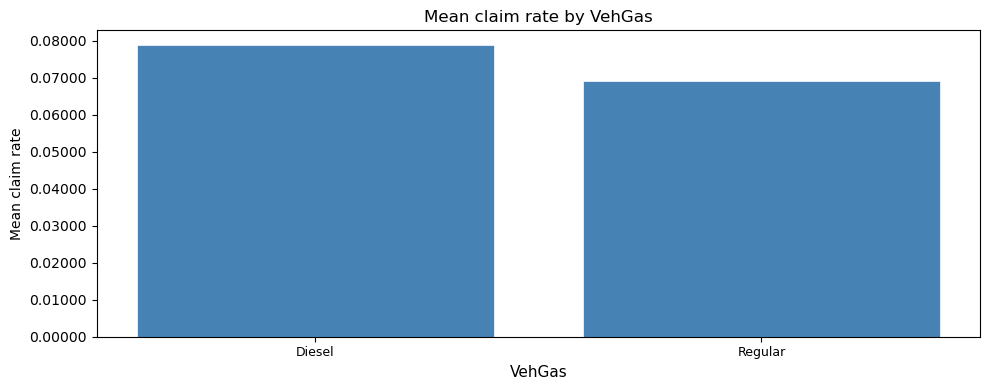

---

### `Region` &nbsp; (22 levels)

,Region,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,Rhone-Alpes,"84,748",12.50%,"84,748","4,233.0","45,343.5",0.093354
1,Picardie,"7,994",1.18%,"7,994",314.0,"3,574.4",0.087847
2,Ile-de-France,"69,789",10.29%,"69,789","2,591.0","30,207.2",0.085774
3,Provence-Alpes-Cotes-D'Azur,"79,315",11.70%,"79,315","2,986.0","35,790.3",0.083430
4,Limousin,"4,567",0.67%,"4,567",197.0,"2,396.0",0.082221
5,Nord-Pas-de-Calais,"27,284",4.02%,"27,284",944.0,"11,497.0",0.082109
6,Alsace,"2,200",0.32%,"2,200",92.0,"1,209.1",0.076089
7,Corse,"4,516",0.67%,"4,516",132.0,"1,765.9",0.074748
8,Aquitaine,"31,329",4.62%,"31,329","1,055.0","14,322.2",0.073662
9,Languedoc-Roussillon,"35,805",5.28%,"35,805","1,068.0","14,736.1",0.072475


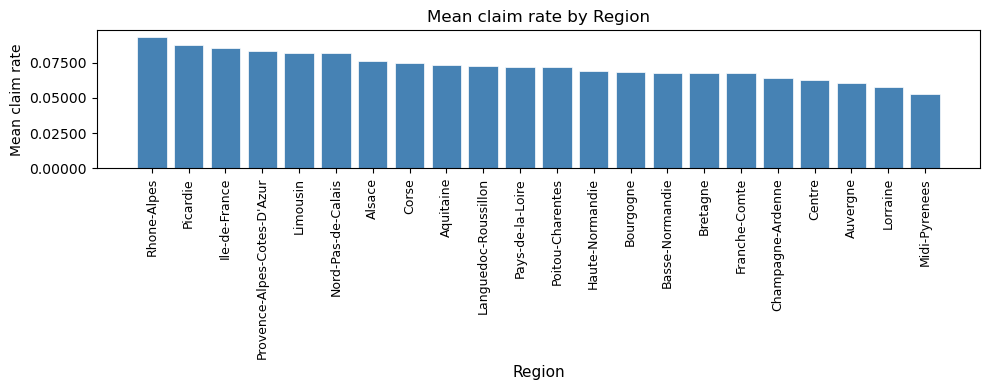

In [5]:
# Feature configuration for freMTPL2freq
#
# order:
#   list      -> explicit level ordering  (Area: A < B < C < D < E < F)
#   'natural' -> ascending by value       (numeric ordinals: VehPower, VehAge, etc.)
#   'rate'    -> descending by claim rate (nominals without natural order: VehBrand, Region)

FREQ_FEATURES = [
    {"col": "Area",       "order": ["A", "B", "C", "D", "E", "F"]},
    {"col": "VehPower",   "order": "natural"},
    {"col": "VehAge",     "order": "natural"},
    {"col": "DrivAge",    "order": "natural"},
    {"col": "BonusMalus", "order": "natural"},
    {"col": "VehBrand",   "order": "rate"},
    {"col": "VehGas",     "order": "rate"},
    {"col": "Region",     "order": "rate"},
]

for feat in FREQ_FEATURES:
    explore_feature(
        df=df_freq,
        col=feat["col"],
        response_col="ClaimNb",
        exposure_col="Exposure",
        order=feat["order"],
    )

---
## 2. French MTPL &mdash; `freMTPL2sev`

**Response:** `ClaimNb` (number of claims per policy)  
**Exposure:** `Exposure` (policy-years)  
**Claim rate:** `sum(ClaimNb) / sum(Exposure)` claims per exposure-year

In [6]:
print(f"Shape: {df_sev.shape[0]:,} rows x {df_sev.shape[1]} columns")
print()
print("Column dtypes:")
print(df_sev.dtypes.to_string())
display(df_sev.head())

Shape: 26,444 rows x 2 columns

Column dtypes:
IDpol              str
ClaimAmount    float64


,IDpol,ClaimAmount
1,1552,995.200000
2,1010996,1128.120000
3,4024277,1851.110000
4,4007252,1204.000000
5,4046424,1204.000000


---
## 3. Belgian MTPL &mdash; `bemtpl`

**Response:** `nclaims` (number of claims per policy)  
**Exposure:** `expo` (policy-years)  
**Claim rate:** `sum(nclaims) / sum(expo)` claims per exposure-year

> `bemtpl` is used for both frequency and severity modelling (Q1 and Q2).  
> This section explores claim **frequency** for all features.

In [7]:
print(f"Shape: {df_bemtpl.shape[0]:,} rows x {df_bemtpl.shape[1]} columns")
print()
print("Column dtypes:")
print(df_bemtpl.dtypes.to_string())
print()
overall_rate_be = df_bemtpl["nclaims"].sum() / df_bemtpl["expo"].sum()
pct_with_claim_be = (df_bemtpl["nclaims"] > 0).mean()
print(f"Overall claim rate : {overall_rate_be:.6f} claims / exposure-year")
print(f"Policies with claim: {pct_with_claim_be:.4%}")
print()
display(df_bemtpl.head())

Shape: 163,212 rows x 18 columns

Column dtypes:
id            int32
expo        float64
claim           str
nclaims       int32
amount      float64
average     float64
coverage        str
ageph         int32
sex             str
bm            int32
power         int32
agec          int32
fuel            str
use             str
fleet           str
postcode      int32
long        float64
lat         float64

Overall claim rate : 0.139206 claims / exposure-year
Policies with claim: 11.1977%



,id,expo,claim,nclaims,amount,average,coverage,ageph,sex,bm,power,agec,fuel,use,fleet,postcode,long,lat
1,1,1.000000,1,1,1618.001036,1618.001036,TPL,50,male,5,77,12,gasoline,private,0,1000,4.355223,50.845386
2,2,1.000000,0,0,0.000000,NaN,TPL+,64,female,5,66,3,gasoline,private,0,1000,4.355223,50.845386
3,3,1.000000,0,0,0.000000,NaN,TPL,60,male,0,70,10,diesel,private,0,1000,4.355223,50.845386
4,4,1.000000,0,0,0.000000,NaN,TPL,77,male,0,57,15,gasoline,private,0,1000,4.355223,50.845386
5,5,0.046575,1,1,155.974606,155.974606,TPL,28,female,9,70,7,gasoline,private,0,1000,4.355223,50.845386


---

### `coverage` &nbsp; (3 levels)

,coverage,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,TPL,"95,124",58.28%,"95,124","12,218.0","83,754.2",0.145879
1,TPL+,"45,984",28.17%,"45,984","5,322.0","41,676.4",0.127698
2,TPL++,"22,104",13.54%,"22,104","2,675.0","19,786.2",0.135195


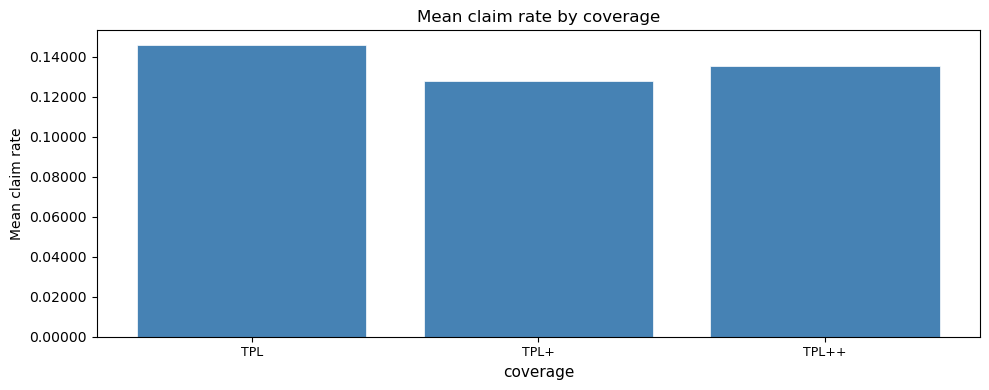

---

### `fuel` &nbsp; (2 levels)

,fuel,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,diesel,"50,394",30.88%,"50,394","7,027.0","44,565.0",0.157680
1,gasoline,"112,818",69.12%,"112,818","13,188.0","100,651.8",0.131026


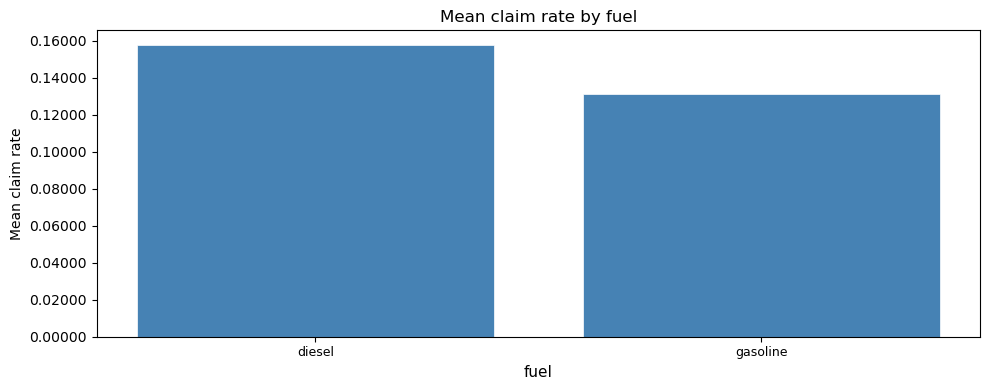

---

### `sex` &nbsp; (2 levels)

,sex,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,female,"43,168",26.45%,"43,168","5,626.0","37,951.3",0.148242
1,male,"120,044",73.55%,"120,044","14,589.0","107,265.5",0.136008


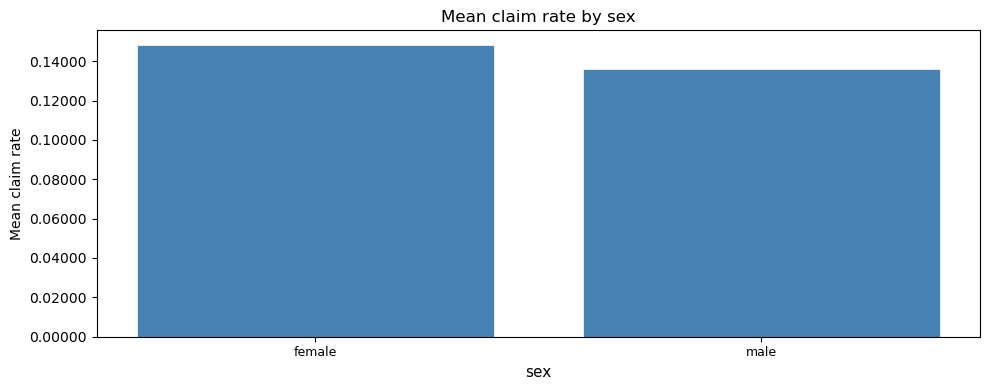

---

### `use` &nbsp; (2 levels)

,use,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,private,"155,334",95.17%,"155,334","19,236.0","138,107.5",0.139283
1,work,"7,878",4.83%,"7,878",979.0,"7,109.4",0.137706


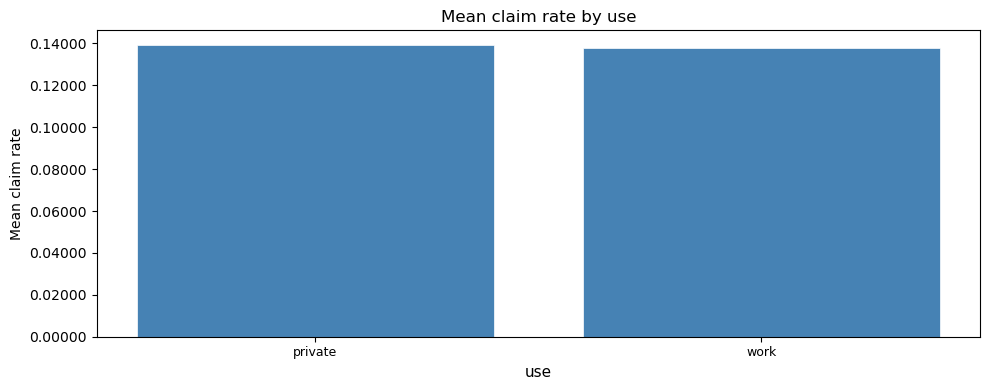

---

### `fleet` &nbsp; (2 levels)

,fleet,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,0,"158,041",96.83%,"158,041","19,663.0","140,259.6",0.140190
1,1,"5,171",3.17%,"5,171",552.0,"4,957.2",0.111353


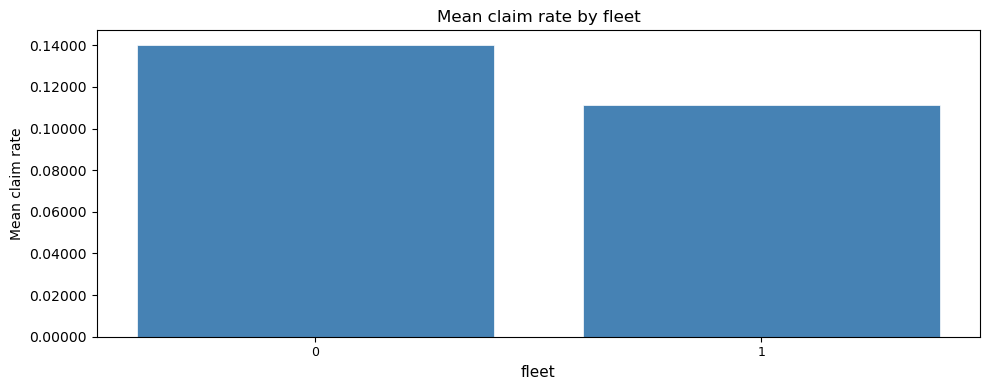

---

### `bm` &nbsp; (23 levels)

,bm,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,0,"61,647",37.77%,"61,647","5,593.0","55,619.0",0.100559
1,1,"26,969",16.52%,"26,969","2,892.0","24,859.3",0.116335
2,2,"9,522",5.83%,"9,522","1,110.0","8,666.9",0.128073
3,3,"3,947",2.42%,"3,947",580.0,"3,285.5",0.176535
4,4,"8,346",5.11%,"8,346","1,070.0","7,256.3",0.147457
5,5,"11,954",7.32%,"11,954","1,579.0","10,933.1",0.144423
6,6,"5,278",3.23%,"5,278",745.0,"4,606.0",0.161745
7,7,"5,266",3.23%,"5,266",835.0,"4,634.3",0.180179
8,8,"4,523",2.77%,"4,523",775.0,"3,858.9",0.200835
9,9,"6,241",3.82%,"6,241","1,030.0","5,458.0",0.188712


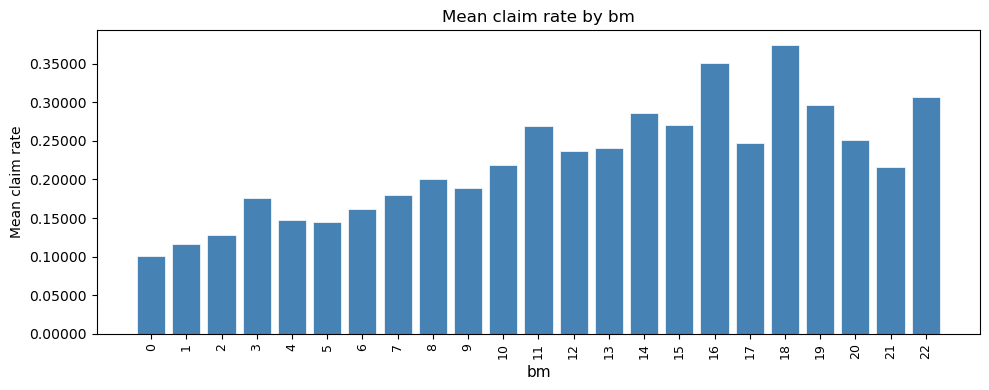

---

### `power` &nbsp; (178 levels)

,power,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,10,1,0.00%,1,1.0,1.0,1.000000
1,13,9,0.01%,9,1.0,7.1,0.141638
2,16,1,0.00%,1,0.0,0.2,0.000000
3,17,3,0.00%,3,0.0,3.0,0.000000
4,18,56,0.03%,56,5.0,45.3,0.110352
5,19,122,0.07%,122,13.0,98.2,0.132350
6,20,5,0.00%,5,0.0,4.1,0.000000
7,21,319,0.20%,319,23.0,275.2,0.083585
8,22,25,0.02%,25,1.0,21.8,0.045952
9,23,5,0.00%,5,0.0,2.9,0.000000


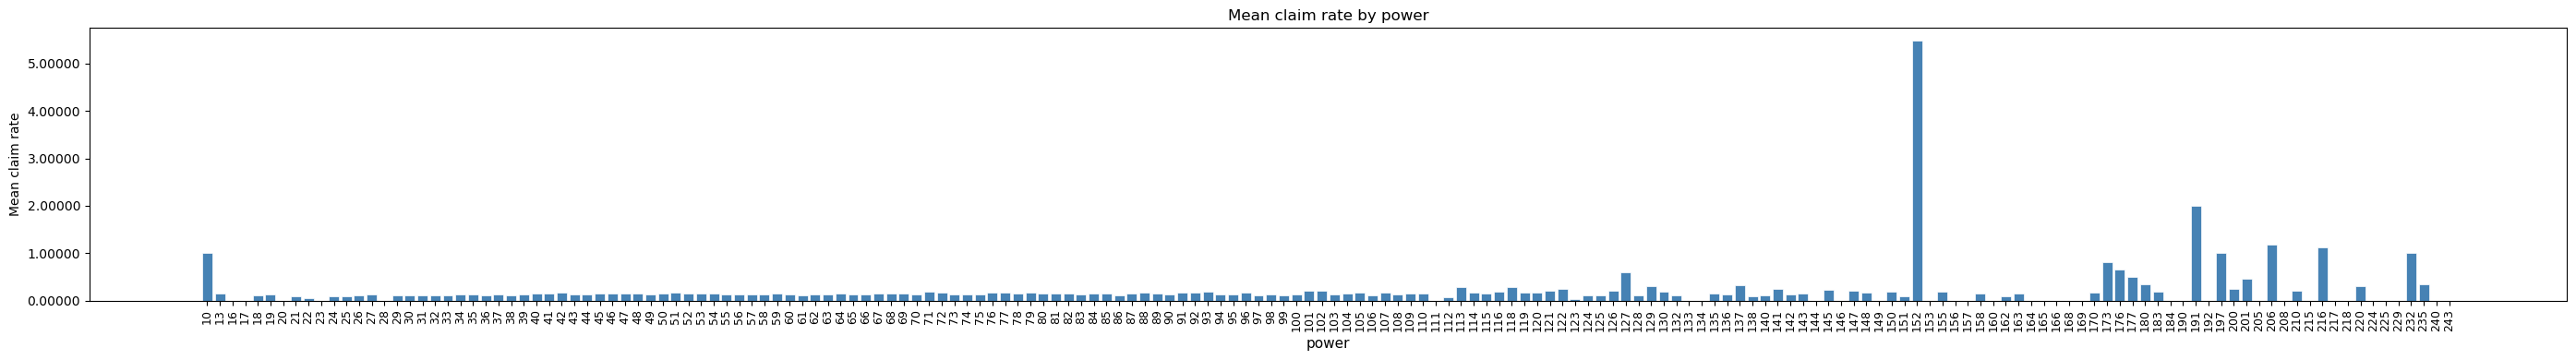

---

### `agec` &nbsp; (49 levels)

,agec,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,0,195,0.12%,195,40.0,190.1,0.210435
1,1,"7,557",4.63%,"7,557","1,073.0","6,366.4",0.168540
2,2,"13,726",8.41%,"13,726","1,561.0","12,099.7",0.129012
3,3,"12,517",7.67%,"12,517","1,383.0","11,231.1",0.123140
4,4,"12,773",7.83%,"12,773","1,550.0","11,524.8",0.134493
5,5,"12,432",7.62%,"12,432","1,513.0","11,233.1",0.134691
6,6,"15,053",9.22%,"15,053","1,861.0","13,607.7",0.136761
7,7,"13,886",8.51%,"13,886","1,777.0","12,582.8",0.141224
8,8,"13,988",8.57%,"13,988","1,765.0","12,649.8",0.139528
9,9,"12,485",7.65%,"12,485","1,561.0","11,221.5",0.139107


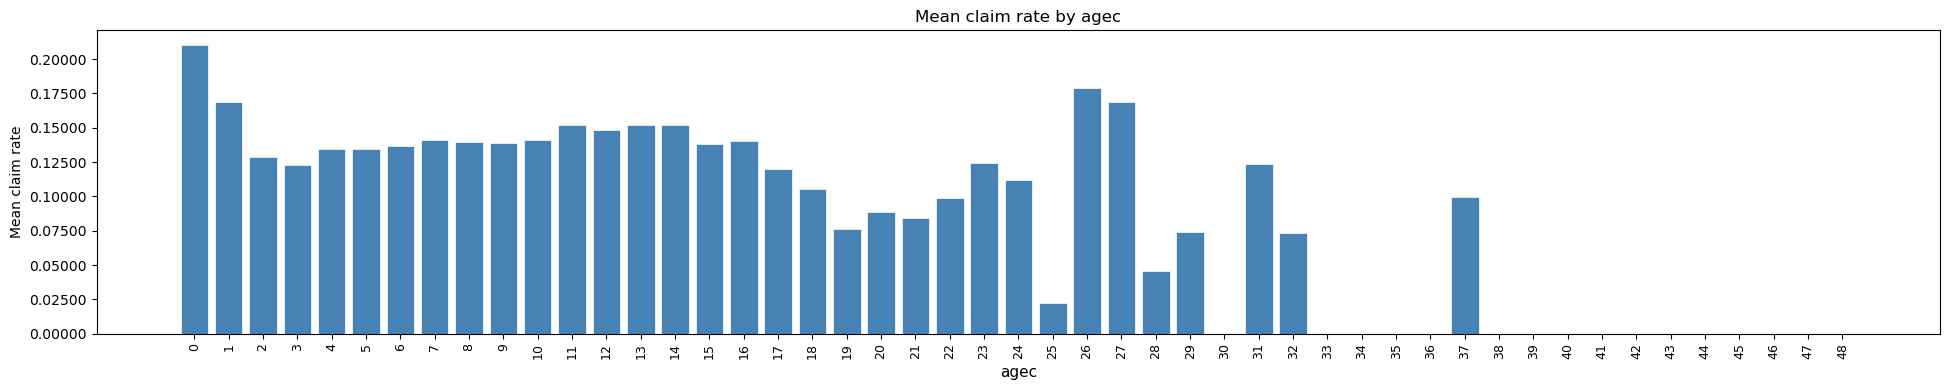

---

### `ageph` &nbsp; (78 levels)

,ageph,count,pct,n_policies,sum_claims,sum_exposure,mean_rate
0,18,16,0.01%,16,5.0,4.6,1.081802
1,19,116,0.07%,116,28.0,93.0,0.301004
2,20,393,0.24%,393,113.0,342.3,0.330134
3,21,700,0.43%,700,164.0,596.4,0.274988
4,22,952,0.58%,952,202.0,778.8,0.259364
5,23,"1,379",0.84%,"1,379",297.0,"1,165.4",0.254857
6,24,"2,028",1.24%,"2,028",426.0,"1,752.2",0.243116
7,25,"2,672",1.64%,"2,672",545.0,"2,342.8",0.232631
8,26,"2,941",1.80%,"2,941",548.0,"2,535.1",0.216166
9,27,"3,130",1.92%,"3,130",520.0,"2,714.7",0.191552


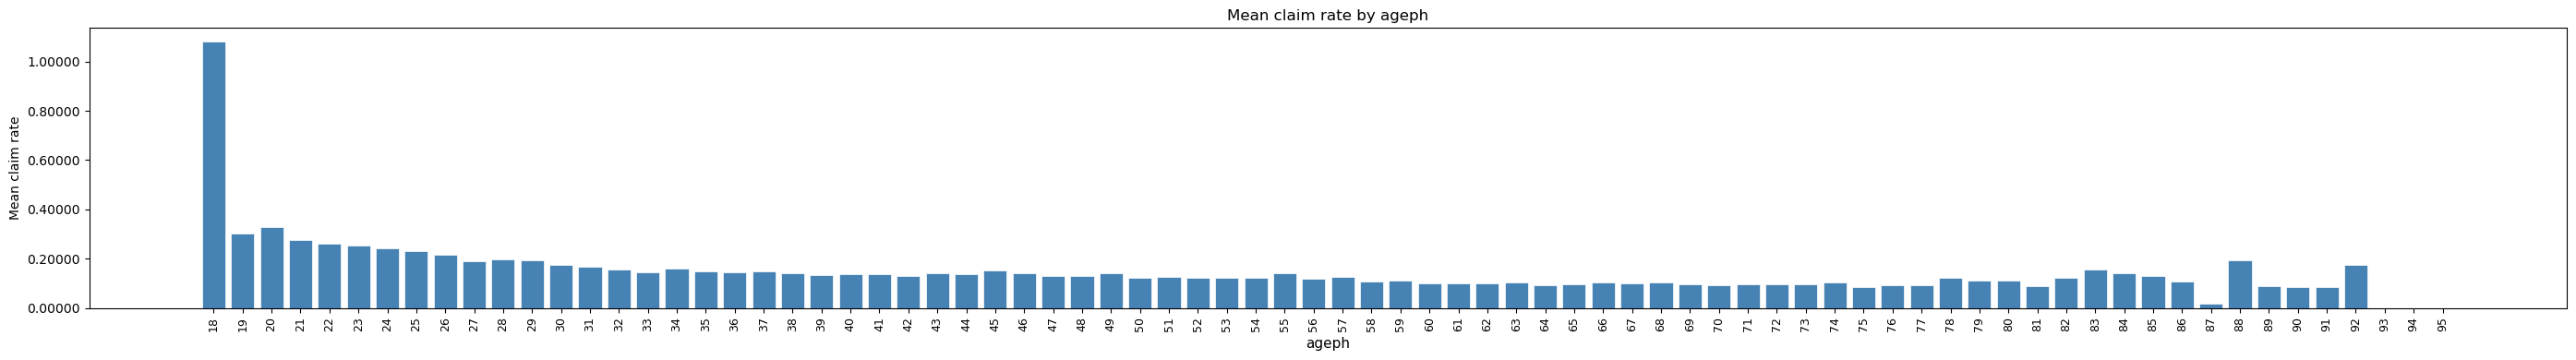

In [8]:
# Feature configuration for bemtpl
#
# coverage has a natural order: TPL < TPL+ < TPL++ (increasing coverage breadth).
# Numeric ordinals (bm, power, agec, ageph) are sorted by their own value.
# Nominal categoricals (fuel, sex, use) are sorted by mean claim rate.
#
# Note: column names are verified from the dtypes printout in the cell above.
# Update this list if the actual dataset uses different column names.

BEMTPL_FEATURES = [
    {"col": "coverage", "order": ["TPL", "TPL+", "TPL++"]},
    {"col": "fuel",     "order": "rate"},
    {"col": "sex",      "order": "rate"},
    {"col": "use",      "order": "rate"},
    {"col": "fleet",    "order": "natural"},
    {"col": "bm",       "order": "natural"},
    {"col": "power",    "order": "natural"},
    {"col": "agec",     "order": "natural"},
    {"col": "ageph",    "order": "natural"},
]

for feat in BEMTPL_FEATURES:
    explore_feature(
        df=df_bemtpl,
        col=feat["col"],
        response_col="nclaims",
        exposure_col="expo",
        order=feat["order"],
    )

## Encoding decisions

> Decisions recorded here will be hard-coded in `config/features.yaml`.

**Type key**
- *ordinal string* — string levels with a meaningful natural order
- *ordinal integer* — integer already on the right scale; pass through as numeric
- *nominal string* — string levels with no natural order
- *nominal string (binary)* — two-level nominal; one-hot and label encoding are equivalent
- *binary string* — stored as `"0"`/`"1"` strings; convert to int before any encoding

| Feature | Dataset | Type | GLM | XGBoost / TabPFN | Notes |
|---|---|---|---|---|---|
| `Area` | freMTPL2freq | ordinal string | one-hot | ordinal encoding | A=0, B=1, C=2, D=3, E=4, F=5 |
| `VehPower` | freMTPL2freq | ordinal integer | as-is (numeric) | as-is (numeric) | |
| `VehAge` | freMTPL2freq | ordinal integer | as-is (numeric) | as-is (numeric) | |
| `DrivAge` | freMTPL2freq | ordinal integer | as-is (numeric) | as-is (numeric) | |
| `BonusMalus` | freMTPL2freq | ordinal integer | as-is (numeric) | as-is (numeric) | |
| `VehBrand` | freMTPL2freq | nominal string | one-hot | label encoding | |
| `VehGas` | freMTPL2freq | nominal string (binary) | binary (0/1) | binary (0/1) | Diesel=0, Regular=1 |
| `Region` | freMTPL2freq | nominal string | one-hot | label encoding | |
| `coverage` | beMTPL97 | ordinal string | one-hot | ordinal encoding | TPL=0, TPL+=1, TPL++=2 |
| `sex` | beMTPL97 | nominal string (binary) | binary (0/1) | binary (0/1) | female=0, male=1 |
| `fuel` | beMTPL97 | nominal string (binary) | binary (0/1) | binary (0/1) | diesel=0, gasoline=1 |
| `use` | beMTPL97 | nominal string | one-hot | label encoding | Levels: private / work / both |
| `fleet` | beMTPL97 | binary string | binary (0/1) | binary (0/1) | Cast str → int directly |
| `bm` | beMTPL97 | ordinal integer | as-is (numeric) | as-is (numeric) | Bonus-malus coefficient |
| `power` | beMTPL97 | ordinal integer | as-is (numeric) | as-is (numeric) | Vehicle horsepower |
| `agec` | beMTPL97 | ordinal integer | as-is (numeric) | as-is (numeric) | Vehicle age in years |
| `ageph` | beMTPL97 | ordinal integer | as-is (numeric) | as-is (numeric) | Policyholder age in years |